In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
# origin_data = pd.read_csv('/content/drive/MyDrive/프로그래머스 데브코스 데이터 분석/3차 프로젝트/train.csv')
# origin_data = pd.read_csv('/content/drive/MyDrive/프로그래머스 데브코스 데이터 분석/3차 프로젝트/test.csv')
# origin_data = pd.read_csv('/content/drive/MyDrive/프로그래머스 데브코스 데이터 분석/3차 프로젝트/sample_submission.csv')
origin_data = pd.read_csv('/content/drive/MyDrive/프로그래머스 데브코스 데이터 분석/3차 프로젝트/newfile.csv')

In [ ]:
print(len(origin_data['Product ID'].unique()))
print(len(origin_data))

9976
136429


In [ ]:
origin_data.head(5)

,Unnamed: 0,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Power,RotationalSpeed_TorqueRatio,ToolWearRate,Temperature_Difference,Average_Temperature,Toolwear_Rate
0,0,0,L50096,L,300.6,309.6,1596,36.1,140,0,57615.6,44.210526,5054.0,9.0,305.10,0.553360
1,1,1,M20343,M,302.6,312.1,1759,29.1,200,0,51186.9,60.446735,5820.0,9.5,307.35,0.790514
2,2,2,L49454,L,299.3,308.5,1805,26.5,25,0,47832.5,68.113208,662.5,9.2,303.90,0.098814
3,3,3,L53355,L,301.0,310.9,1524,44.3,197,0,67513.2,34.401806,8727.1,9.9,305.95,0.778656
4,4,4,M24050,M,298.0,309.0,1641,35.4,34,0,58091.4,46.355932,1203.6,11.0,303.50,0.134387


In [ ]:
origin_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   136429 non-null  int64  
 1   id                           136429 non-null  int64  
 2   Product ID                   136429 non-null  object 
 3   Type                         136429 non-null  object 
 4   Air temperature [K]          136429 non-null  float64
 5   Process temperature [K]      136429 non-null  float64
 6   Rotational speed [rpm]       136429 non-null  int64  
 7   Torque [Nm]                  136429 non-null  float64
 8   Tool wear [min]              136429 non-null  int64  
 9   Machine failure              136429 non-null  int64  
 10  Power                        136429 non-null  float64
 11  RotationalSpeed_TorqueRatio  136429 non-null  float64
 12  ToolWearRate                 136429 non-null  float64
 13 

In [ ]:
origin_data.describe()

,Unnamed: 0,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Power,RotationalSpeed_TorqueRatio,ToolWearRate,Temperature_Difference,Average_Temperature,Toolwear_Rate
count,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000
mean,68214.000000,68214.000000,299.862776,309.941070,1520.331110,40.348643,104.408901,0.015744,60423.953944,40.509449,4211.045235,10.078295,304.901923,0.412683
std,39383.804275,39383.804275,1.862247,1.385173,138.736632,8.502229,63.965040,0.124486,9531.546208,16.821796,2777.959897,0.984934,1.565507,0.252826
min,0.000000,0.000000,295.300000,305.800000,1181.000000,3.800000,0.000000,0.000000,5829.600000,15.665796,0.000000,3.200000,300.550000,0.000000
25%,34107.000000,34107.000000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,54199.700000,31.285403,1851.800000,9.300000,303.550000,0.189723
50%,68214.000000,68214.000000,300.000000,310.000000,1493.000000,40.400000,106.000000,0.000000,60258.000000,36.900726,4083.200000,9.900000,304.950000,0.418972
75%,102321.000000,102321.000000,301.200000,310.900000,1580.000000,46.100000,159.000000,0.000000,66502.200000,45.346821,6253.200000,11.000000,306.050000,0.628458
max,136428.000000,136428.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,152856.200000,752.894737,15608.800000,15.000000,309.050000,1.000000


In [ ]:
origin_data

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse=False)

Type_array = ohe.fit_transform(origin_data[['Type']])

Type_data = pd.DataFrame(ohe.transform(origin_data[['Type']]), columns=['M', 'L', 'H'])

origin_data = pd.concat([origin_data, Type_data], axis=1)

origin_data = origin_data.drop(columns=['Type'])

origin_data.head(5)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,Unnamed: 0,id,Product ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Power,RotationalSpeed_TorqueRatio,ToolWearRate,Temperature_Difference,Average_Temperature,Toolwear_Rate,M,L,H
0,0,0,L50096,300.6,309.6,1596,36.1,140,0,57615.6,44.210526,5054.0,9.0,305.10,0.553360,0.0,1.0,0.0
1,1,1,M20343,302.6,312.1,1759,29.1,200,0,51186.9,60.446735,5820.0,9.5,307.35,0.790514,0.0,0.0,1.0
2,2,2,L49454,299.3,308.5,1805,26.5,25,0,47832.5,68.113208,662.5,9.2,303.90,0.098814,0.0,1.0,0.0
3,3,3,L53355,301.0,310.9,1524,44.3,197,0,67513.2,34.401806,8727.1,9.9,305.95,0.778656,0.0,1.0,0.0
4,4,4,M24050,298.0,309.0,1641,35.4,34,0,58091.4,46.355932,1203.6,11.0,303.50,0.134387,0.0,0.0,1.0


In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columns_to_normalize = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]','Power','RotationalSpeed_TorqueRatio','ToolWearRate','Temperature_Difference','Average_Temperature','Toolwear_Rate']

data_normalized = scaler.fit_transform(origin_data[columns_to_normalize])

for i, col in enumerate(columns_to_normalize):
    origin_data[col + '_normalized'] = data_normalized[:, i]

origin_data = origin_data.drop(columns = columns_to_normalize)

In [ ]:
origin_data = pd.concat([origin_data[origin_data['Machine failure'] == 0].sample(n=6000, random_state=42),origin_data[origin_data['Machine failure'] == 1]],axis=0)

In [27]:
origin_data.drop(columns=['Toolwear_Rate_normalized','Average_Temperature_normalized'],inplace=True)

In [ ]:
origin_data = origin_data[['Power_normalized','Torque [Nm]_normalized','RotationalSpeed_TorqueRatio_normalized','Temperature_Difference_normalized','Machine failure']]

In [ ]:
origin_data.drop(columns = ['Average_Temperature_normalized','Rotational speed [rpm]_normalized','Process temperature [K]_normalized','Air temperature [K]_normalized'],inplace=True)

In [6]:
origin_data.head(5)

,Unnamed: 0,id,Product ID,Type,Machine failure,Air temperature [K]_normalized,Process temperature [K]_normalized,Rotational speed [rpm]_normalized,Torque [Nm]_normalized,Tool wear [min]_normalized,Power_normalized,RotationalSpeed_TorqueRatio_normalized,ToolWearRate_normalized,Temperature_Difference_normalized
0,0,0,L50096,L,0,0.582418,0.4750,0.243402,0.443681,0.553360,0.352222,0.038719,0.323792,0.491525
1,1,1,M20343,M,0,0.802198,0.7875,0.339003,0.347527,0.790514,0.308497,0.060742,0.372867,0.533898
2,2,2,L49454,L,0,0.439560,0.3375,0.365982,0.311813,0.098814,0.285682,0.071141,0.042444,0.508475
3,3,3,L53355,L,0,0.626374,0.6375,0.201173,0.556319,0.778656,0.419540,0.025414,0.559114,0.567797
4,4,4,M24050,M,0,0.296703,0.4000,0.269795,0.434066,0.134387,0.355458,0.041629,0.077110,0.661017


In [28]:
for i in ['Unnamed: 0','id','Product ID','Type','TWF','HDF','PWF','OSF','RNF']:
  if i in origin_data.columns:
    origin_data.drop(columns = [i],inplace=True)

data = origin_data

In [ ]:
data.corr()

,Machine failure,Air temperature [K]_normalized,Process temperature [K]_normalized,Rotational speed [rpm]_normalized,Torque [Nm]_normalized,Tool wear [min]_normalized,Power_normalized,RotationalSpeed_TorqueRatio_normalized,ToolWearRate_normalized,Temperature_Difference_normalized
Machine failure,1.000000,0.067744,0.030966,-0.060868,0.145793,0.056448,0.128222,-0.002887,0.111041,-0.084536
Air temperature [K]_normalized,0.067744,1.000000,0.856080,0.016545,-0.006773,0.016994,-0.004496,0.016558,0.014314,-0.686776
Process temperature [K]_normalized,0.030966,0.856080,1.000000,0.011263,-0.006298,0.012777,-0.004679,0.010883,0.010579,-0.212257
Rotational speed [rpm]_normalized,-0.060868,0.016545,0.011263,1.000000,-0.779394,0.003983,-0.584267,0.851067,-0.247731,-0.015443
Torque [Nm]_normalized,0.145793,-0.006773,-0.006298,-0.779394,1.000000,-0.003148,0.952142,-0.798272,0.318195,0.003949
Tool wear [min]_normalized,0.056448,0.016994,0.012777,0.003983,-0.003148,1.000000,-0.003431,0.005784,0.926409,-0.014162
Power_normalized,0.128222,-0.004496,-0.004679,-0.584267,0.952142,-0.003431,1.000000,-0.730256,0.301894,0.001920
RotationalSpeed_TorqueRatio_normalized,-0.002887,0.016558,0.010883,0.851067,-0.798272,0.005784,-0.730256,1.000000,-0.252850,-0.016001
ToolWearRate_normalized,0.111041,0.014314,0.010579,-0.247731,0.318195,0.926409,0.301894,-0.252850,1.000000,-0.012185
Temperature_Difference_normalized,-0.084536,-0.686776,-0.212257,-0.015443,0.003949,-0.014162,0.001920,-0.016001,-0.012185,1.000000


In [ ]:
# 오버샘플링
from imblearn.over_sampling import SMOTE

# 데이터와 라벨을 준비
X = data.drop('Machine failure', axis=1)  # 특성
y = data['Machine failure']  # 라벨

# SMOTE 인스턴스 생성
smote = SMOTE(random_state=42)

# 오버샘플링 적용
X_res, y_res = smote.fit_resample(X, y)

data = pd.concat([X_res,y_res],axis=1)

# 결과 확인
print(f'Original dataset shape {y.value_counts()}')
print(f'Resampled dataset shape {y_res.value_counts()}')

Original dataset shape Machine failure
0    134281
1      2148
Name: count, dtype: int64
Resampled dataset shape Machine failure
0    134281
1    134281
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import RandomOverSampler

# 데이터와 라벨을 준비
X = data.drop('Machine failure', axis=1)  # 특성
y = data['Machine failure']  # 라벨

# RandomUnderSampler 인스턴스 생성
rus = RandomOverSampler(random_state=42)

# 언더샘플링 적용
X_res, y_res = rus.fit_resample(X, y)

data = pd.concat([X_res,y_res],axis=1)

# 결과 확인
print(f'Original dataset shape {y.value_counts()}')
print(f'Resampled dataset shape {y_res.value_counts()}')

Original dataset shape Machine failure
0    134281
1      2148
Name: count, dtype: int64
Resampled dataset shape Machine failure
0    134281
1    134281
Name: count, dtype: int64


In [8]:
# 언더샘플링
from imblearn.under_sampling import RandomUnderSampler

# 데이터와 라벨을 준비
X = data.drop('Machine failure', axis=1)  # 특성
y = data['Machine failure']  # 라벨

# RandomUnderSampler 인스턴스 생성
rus = RandomUnderSampler(random_state=42)

# 언더샘플링 적용
X_res, y_res = rus.fit_resample(X, y)

data = pd.concat([X_res,y_res],axis=1)

# 결과 확인
print(f'Original dataset shape {y.value_counts()}')
print(f'Resampled dataset shape {y_res.value_counts()}')


Original dataset shape Machine failure
0    134281
1      2148
Name: count, dtype: int64
Resampled dataset shape Machine failure
0    2148
1    2148
Name: count, dtype: int64


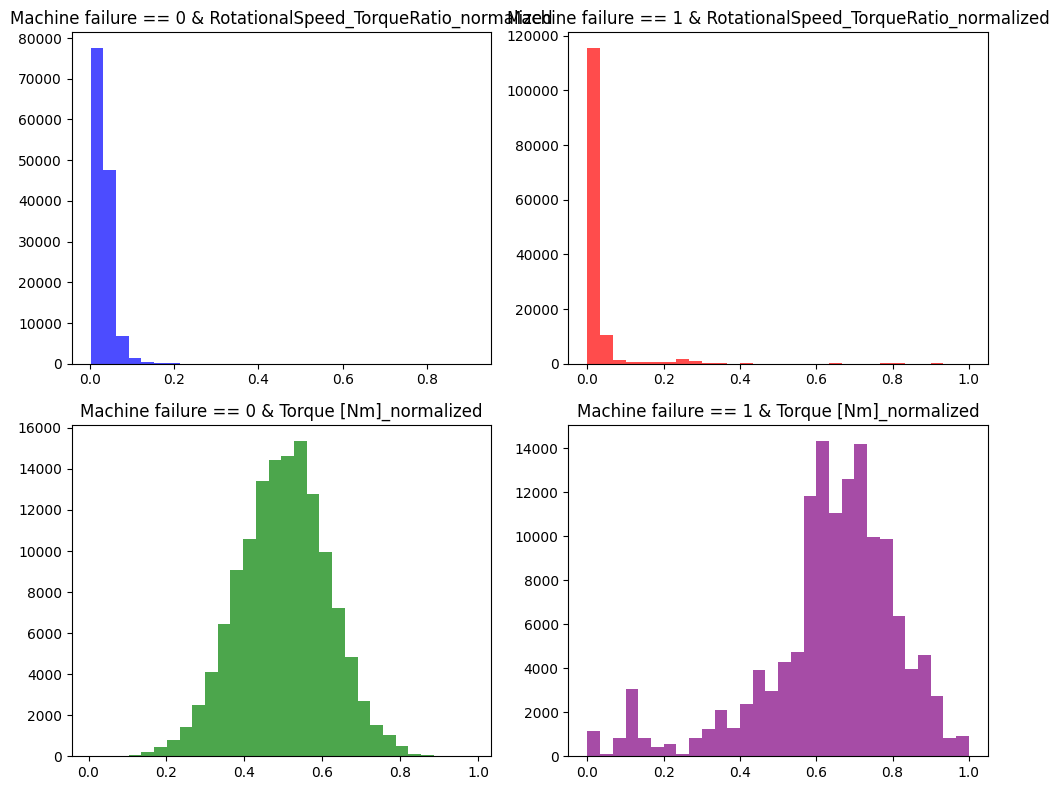

In [ ]:
data[data['Machine failure']==0]['RotationalSpeed_TorqueRatio_normalized']

# Figure 생성
plt.figure(figsize=(10, 8))  # 전체 Figure 크기 설정

# 첫 번째 그래프 (1행 1열 위치)
plt.subplot(2, 2, 1)  # 2행 2열의 1번 위치
plt.hist(data[data['Machine failure']==0]['RotationalSpeed_TorqueRatio_normalized'], bins=30, color='blue', alpha=0.7)
plt.title('Machine failure == 0 & RotationalSpeed_TorqueRatio_normalized')

# 두 번째 그래프 (1행 2열 위치)
plt.subplot(2, 2, 2)  # 2행 2열의 2번 위치
plt.hist(data[data['Machine failure']==1]['RotationalSpeed_TorqueRatio_normalized'], bins=30, color='red', alpha=0.7)
plt.title('Machine failure == 1 & RotationalSpeed_TorqueRatio_normalized')

# 세 번째 그래프 (2행 1열 위치)
plt.subplot(2, 2, 3)  # 2행 2열의 3번 위치
plt.hist(data[data['Machine failure']==0]['Torque [Nm]_normalized'], bins=30, color='green', alpha=0.7)
plt.title('Machine failure == 0 & Torque [Nm]_normalized')

# 네 번째 그래프 (2행 2열 위치)
plt.subplot(2, 2, 4)  # 2행 2열의 4번 위치
plt.hist(data[data['Machine failure']==1]['Torque [Nm]_normalized'], bins=30, color='purple', alpha=0.7)
plt.title('Machine failure == 1 & Torque [Nm]_normalized')

# 레이아웃 조정
plt.tight_layout()
plt.show()

#모델 학습 & 성능 평가 (Logistic Regression)

타임 라인 :
1. 원본 데이터 그대로 모델링(문자열 데이터 제외) -> 정확도 : 98%
2. Type을 OneHotencoding으로 처리한 후 모델링 -> 정확도 : 97%
3. 기계 고장 Yes/No 비율을 1:2.5로 맞추고 모델링 -> 83%
4. 기계 고장 Yes/No 비율을 1:1.5로 맞추고 숫자 컬럼 정규화한 후 모델링 -> 78%
5. 컬럼 추가 후 모델링 -> (행 개수 조절 전 : 98% / 행 개수 조절 후 : 78%)
6. 오버 샘플링/언더 샘플링 -> 81% / 78%
7. 모델 파라미터 수정 -> 정확도 : 83%, F1 Score 0.81
8. 검증 방식 변경(train 데이터 split 후 오버 샘플링) -> 정확도 : 83%, F1 Score : 0.13
9. train 데이터의 행 개수를 3000/2000으로 조정 -> 정확도 : 80%, F1 Score : 0.76

데이터셋 크기에 따른 지표 변화:

2000 :
Accuracy: 0.79
AUC Score: 0.87
Precision: 0.82
Recall: 0.76
F1 Score: 0.79

3000 :
Accuracy: 0.80
AUC Score: 0.86
Precision: 0.75
Recall: 0.78
F1 Score: 0.76

4000 :
Accuracy: 0.80
AUC Score: 0.85
Precision: 0.70
Recall: 0.77
F1 Score: 0.73

5000 :
Accuracy: 0.81
AUC Score: 0.86
Precision: 0.66
Recall: 0.77
F1 Score: 0.71

6000 :
Accuracy: 0.82
AUC Score: 0.86
Precision: 0.62
Recall: 0.77
F1 Score: 0.69

In [29]:
y_column = ['Machine failure']

In [30]:
from sklearn.model_selection import train_test_split

X = data.drop(y_column, axis=1)
y = data[y_column]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,stratify=y)

In [31]:
# 오버샘플링
from imblearn.over_sampling import SMOTE

# 데이터와 라벨을 준비
X = X_train  # 특성
y = y_train  # 라벨

# SMOTE 인스턴스 생성
smote = SMOTE(random_state=42)

# 오버샘플링 적용
X_train, y_train = smote.fit_resample(X, y)

# 결과 확인
print(f'Original dataset shape {y.value_counts()}')
print(f'Resampled dataset shape {y_train.value_counts()}')

Original dataset shape Machine failure
0                  107425
1                    1718
Name: count, dtype: int64
Resampled dataset shape Machine failure
0                  107425
1                  107425
Name: count, dtype: int64


In [32]:
from sklearn.linear_model import LogisticRegression

# 선형 회귀 모델 초기화 및 학습
# logistic_reg = LogisticRegression()
logistic_reg = LogisticRegression(C=100, penalty='l1', solver='liblinear')
# logistic_reg = LogisticRegression(C=10, penalty='l1', solver='saga')
# logistic_reg = LogisticRegression(C=100, penalty='l1', solver='saga', class_weight='balanced')
logistic_reg.fit(X_train, y_train)
# 'C': 100, 'penalty': 'l1', 'solver': 'saga'

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(C=100, penalty='l1', solver='liblinear')

In [43]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

# 예측 수행
y_pred = logistic_reg.predict(X_train)
y_proba = logistic_reg.predict_proba(X_train)[:, 1]  # AUC를 계산하기 위해 확률 예측 필요

# 임계값을 0.5로 설정
threshold = 0.7
y_pred_from_proba = (y_proba > threshold).astype(int)

# 정확도 (Accuracy)
accuracy = accuracy_score(y_train, y_pred_from_proba)
print(f"Accuracy: {accuracy}")

# AUC Score
auc_score = roc_auc_score(y_train, y_pred_from_proba)
print(f"AUC Score: {auc_score}")

# Precision (정밀도)
precision = precision_score(y_train, y_pred_from_proba)
print(f"Precision: {precision}")

# Recall (재현율)
recall = recall_score(y_train, y_pred_from_proba)
print(f"Recall: {recall}")

# F1 Score
f1 = f1_score(y_train, y_pred_from_proba)
print(f"F1 Score: {f1}")

cm_train = confusion_matrix(y_train, y_pred_from_proba)
print(cm_train)

Accuracy: 0.7983337212008378
AUC Score: 0.7983337212008378
Precision: 0.9081831497166146
Recall: 0.6637747265534093
F1 Score: 0.766978595245778
[[100216   7209]
 [ 36119  71306]]


In [44]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

# 예측 수행
y_pred = logistic_reg.predict(X_test)
y_proba = logistic_reg.predict_proba(X_test)[:, 1]  # AUC를 계산하기 위해 확률 예측 필요

# 임계값을 0.5로 설정
threshold = 0.7
y_pred_from_proba = (y_proba > threshold).astype(int)

# 정확도 (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# AUC Score
auc_score = roc_auc_score(y_test, y_proba)
print(f"AUC Score: {auc_score:.2f}")

# Precision (정밀도)
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")

# Recall (재현율)
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.2f}")

# F1 Score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.2f}")

cm_test = confusion_matrix(y_test, y_pred_from_proba)
print(cm_test)

Accuracy: 0.83
AUC Score: 0.87
Precision: 0.07
Recall: 0.78
F1 Score: 0.13
[[25048  1808]
 [  160   270]]


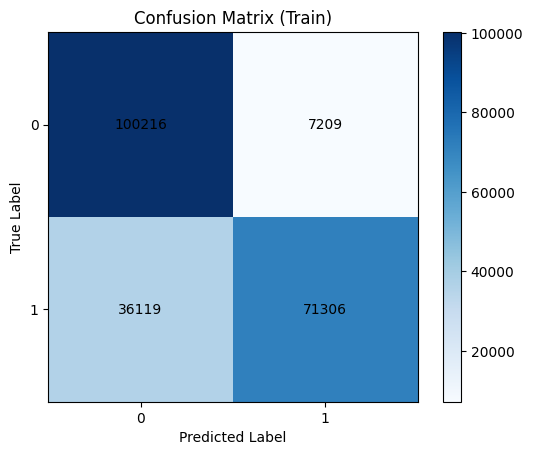

In [35]:
# 학습 데이터를 활용한 confusion matrix

plt.imshow(cm_train, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix (Train)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_train)))
plt.xticks(tick_marks, np.unique(y_train))
plt.yticks(tick_marks, np.unique(y_train))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 셀에 숫자 표시
for i in range(cm_train.shape[0]):
    for j in range(cm_train.shape[1]):
        plt.text(j, i, cm_train[i, j], ha="center", va="center", color="black")


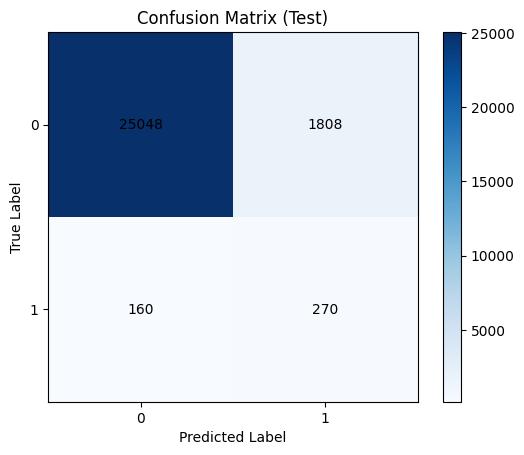

In [36]:
# 평가 데이터를 활용한 confusion matrix

plt.imshow(cm_test, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 셀에 숫자 표시
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        plt.text(j, i, cm_test[i, j], ha="center", va="center", color="black")

In [37]:
coeff_df = pd.DataFrame({'feature': X_train.columns, 'coefficient': logistic_reg.coef_.flatten()})

# 계수의 절대값을 기준으로 내림차순 정렬
coeff_df['abs_coefficient'] = coeff_df['coefficient'].abs()
coeff_df_sorted = coeff_df.sort_values(by='abs_coefficient', ascending=False)

# 변수의 영향력을 확인
coeff_df_sorted

,feature,coefficient,abs_coefficient
6,RotationalSpeed_TorqueRatio_normalized,73.098431,73.098431
3,Torque [Nm]_normalized,23.882202,23.882202
8,Temperature_Difference_normalized,-10.447328,10.447328
5,Power_normalized,-9.794358,9.794358
4,Tool wear [min]_normalized,4.079713,4.079713
1,Process temperature [K]_normalized,2.834816,2.834816
2,Rotational speed [rpm]_normalized,-2.737502,2.737502
0,Air temperature [K]_normalized,-2.729071,2.729071
7,ToolWearRate_normalized,-2.693922,2.693922


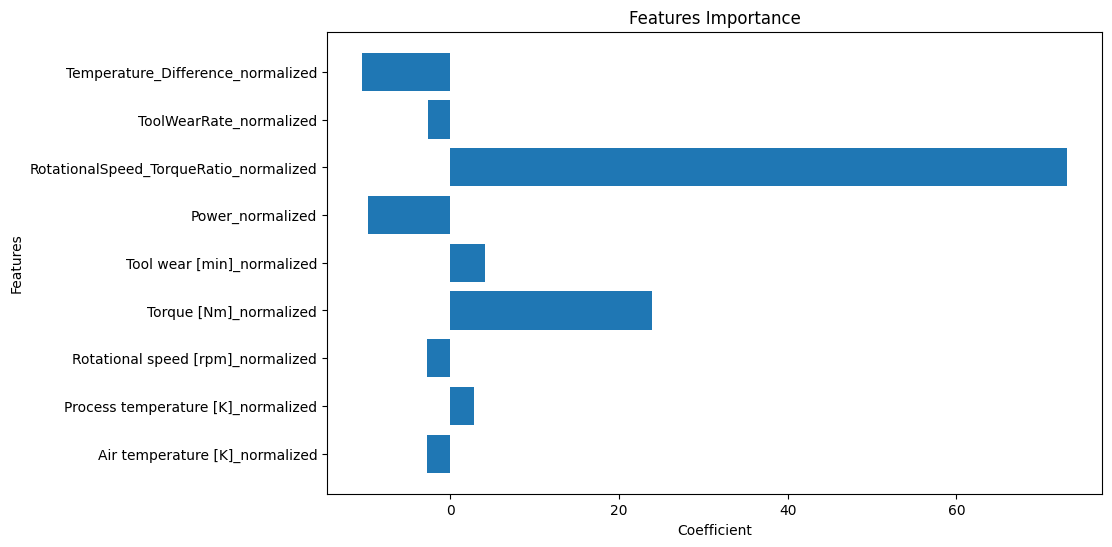

In [38]:
# 변수 영향력 시각화
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns, logistic_reg.coef_.flatten())
plt.xlabel('Coefficient')
plt.ylabel('Features')
plt.title('Features Importance')
plt.show()

In [39]:
from sklearn.model_selection import GridSearchCV

# 파라미터 그리드 설정
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']  # l1 penalty를 사용할 때는 'liblinear'나 'saga' solver가 필요
}

# GridSearchCV 설정
grid_search = GridSearchCV(estimator=logistic_reg, param_grid=param_grid, cv=2, scoring='accuracy')

# 그리드 서치 실행
grid_search.fit(X_train, y_train)

# 결과 출력
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

# 테스트 세트에서 성능 평가
test_score = grid_search.score(X_test, y_test)
print("Test set score: {:.2f}".format(test_score))

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

Best parameters: {'C': 100, 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation score: 0.81
Test set score: 0.83


# 모델 학습 & 성능 평가 (베르누이 나이브 베이지안)

In [ ]:
y_column = ['Machine failure']

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop(y_column, axis=1)
y = data[y_column]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,stratify=y)

In [ ]:
from sklearn.naive_bayes import BernoulliNB

# 선형 회귀 모델 초기화 및 학습
# logistic_reg = LogisticRegression()
BNB_model = BernoulliNB(alpha=1.0)
BNB_model.fit(X_train, y_train)


# 학습된 모델의 계수(coefficients) 및 절편(intercept) 출력
# coefficients = BNB_model.coef_
# intercept = BNB_model.intercept_

# print('#'*20, '학습된 파라미터 값', '#'*20)
# print(coefficients)

# print('#'*20, '학습된 절편 값', '#'*20)
# print(intercept)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


BernoulliNB()

In [ ]:
from sklearn.metrics import accuracy_score

# 예측 수행
y_train_pred = BNB_model.predict(X_train)
y_test_pred = BNB_model.predict(X_test)

# 평가 지표 계산: 정확도 (맞은수/전체)
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print('학습 데이터를 이용한 Acc 값 :', acc_train)
print('평가 데이터를 이용한 Acc 값 :', acc_test)


학습 데이터를 이용한 Acc 값 : 0.958890646723237
평가 데이터를 이용한 Acc 값 : 0.9588686481303931


In [ ]:
from sklearn.model_selection import cross_val_score

k_fold_score = np.mean(cross_val_score(BNB_model, X, y, cv=2))
print(f'K-Fold CV 결과 정확도 : {k_fold_score*100:.2f} %')

K-Fold CV 결과 정확도 : 95.88 %


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

stratified_cv_score = np.mean(cross_val_score(BNB_model, X, y, cv=StratifiedKFold(5)))
print(f'Stratified CV 결과 정확도 : {stratified_cv_score*100:.2f} %')

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Stratified CV 결과 정확도 : 95.88 %


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
from sklearn.metrics import f1_score

print(f1_score(y_train,y_train_pred,average='micro'))
print(f1_score(y_train,y_train_pred,average='weighted'))
print(f1_score(y_train,y_train_pred,average='macro'))
print(f1_score(y_train,y_train_pred,average=None))
print(f1_score(y_train,y_train_pred,average='micro',labels=[0]))

0.958890646723237
0.9388390236772693
0.49124938318413197
[0.97901242 0.00348635]
0.9790124212200942


In [ ]:
# Confusion matrix 생성을 위한 준비
from sklearn.metrics import confusion_matrix

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

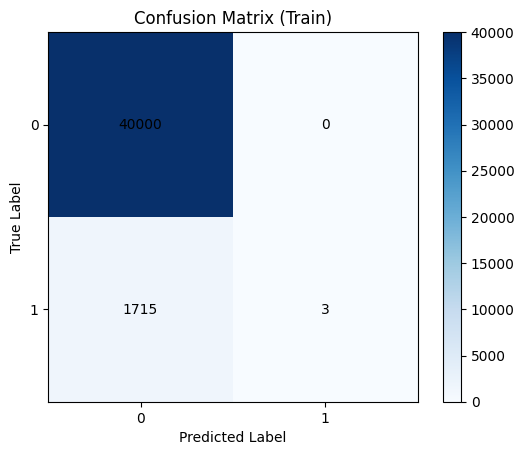

In [ ]:
# 학습 데이터를 활용한 confusion matrix

plt.imshow(cm_train, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix (Train)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_train)))
plt.xticks(tick_marks, np.unique(y_train))
plt.yticks(tick_marks, np.unique(y_train))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 셀에 숫자 표시
for i in range(cm_train.shape[0]):
    for j in range(cm_train.shape[1]):
        plt.text(j, i, cm_train[i, j], ha="center", va="center", color="black")


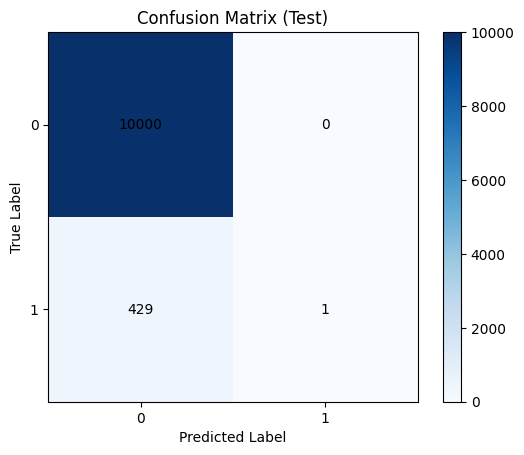

In [ ]:
# 평가 데이터를 활용한 confusion matrix

plt.imshow(cm_test, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 셀에 숫자 표시
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        plt.text(j, i, cm_test[i, j], ha="center", va="center", color="black")

# 모델 학습 & 성능 평가 (XGBoost)

In [ ]:
y_column = ['Machine failure']
data.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in data.columns]

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop(y_column, axis=1)
y = data[y_column]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,stratify=y)

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'max_depth': 3,  # 트리의 최대 깊이
    'eta': 0.1,      # 학습률
    'objective': 'binary:logistic',  # 이진 분류 문제
    'eval_metric': 'logloss'  # 평가 지표 설정
}
num_rounds = 100

# 모델 초기화 및 학습
bst = xgb.train(params, dtrain, num_rounds, evals=[(dtest, 'test')])

predictions = bst.predict(dtest)
# 예측 결과를 이진 라벨로 변환 (0.5 임계값)
predictions = (predictions > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))


[0]	test-logloss:0.64400
[1]	test-logloss:0.60327
[2]	test-logloss:0.56984
[3]	test-logloss:0.54072
[4]	test-logloss:0.51580
[5]	test-logloss:0.49426
[6]	test-logloss:0.47555
[7]	test-logloss:0.45946
[8]	test-logloss:0.44489
[9]	test-logloss:0.43260
[10]	test-logloss:0.42120
[11]	test-logloss:0.41180
[12]	test-logloss:0.40307
[13]	test-logloss:0.39515
[14]	test-logloss:0.38784
[15]	test-logloss:0.38178
[16]	test-logloss:0.37597
[17]	test-logloss:0.37072
[18]	test-logloss:0.36557
[19]	test-logloss:0.36118
[20]	test-logloss:0.35732
[21]	test-logloss:0.35401
[22]	test-logloss:0.35027
[23]	test-logloss:0.34730
[24]	test-logloss:0.34477
[25]	test-logloss:0.34214
[26]	test-logloss:0.33930
[27]	test-logloss:0.33734
[28]	test-logloss:0.33509
[29]	test-logloss:0.33320
[30]	test-logloss:0.33159
[31]	test-logloss:0.33024
[32]	test-logloss:0.32853
[33]	test-logloss:0.32737
[34]	test-logloss:0.32586
[35]	test-logloss:0.32484
[36]	test-logloss:0.32378
[37]	test-logloss:0.32272
[38]	test-logloss:0.32

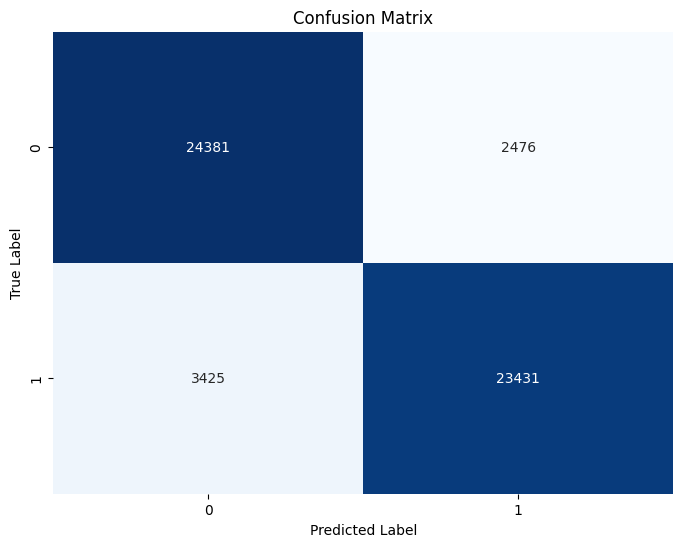

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Confusion Matrix 생성
cm = confusion_matrix(y_test, predictions)

# Confusion Matrix 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


#모델 학습 & 성능 평가 (Random Forest)

1. Type, Average Temperature, toolwear_rate 컬럼 제거 & 오버 샘플링 -> 정확도 : 98% / F1 Score : 0.98
2. Type, Average Temperature, toolwear_rate 컬럼 제거 & 언더 샘플링 -> 정확도 : 100% / F1 Score : 1.0

In [ ]:
y_column = ['Machine failure']

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop(y_column, axis=1)
y = data[y_column]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,stratify=y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 선형 회귀 모델 초기화 및 학습
RFC_model = RandomForestClassifier()
RFC_model.fit(X_train, y_train)


# # 학습된 모델의 계수(coefficients) 및 절편(intercept) 출력
# coefficients = RFC_model.coef_
# intercept = RFC_model.intercept_

# print('#'*20, '학습된 파라미터 값', '#'*20)
# print(coefficients)

# print('#'*20, '학습된 절편 값', '#'*20)
# print(intercept)

<ipython-input-31-cdc1433014ab>:5: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  RFC_model.fit(X_train, y_train)


RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

# 예측 수행
y_train_pred = RFC_model.predict(X_train)
y_test_pred = RFC_model.predict(X_test)

# 평가 지표 계산: 정확도 (맞은수/전체)
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print('학습 데이터를 이용한 Acc 값 :', acc_train)
print('평가 데이터를 이용한 Acc 값 :', acc_test)


학습 데이터를 이용한 Acc 값 : 0.9995857555771728
평가 데이터를 이용한 Acc 값 : 0.9845661199337218


In [ ]:
from sklearn.model_selection import cross_val_score

k_fold_score = np.mean(cross_val_score(RFC_model, X, y, cv=2))
print(f'K-Fold CV 결과 정확도 : {k_fold_score*100:.2f} %')

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)


K-Fold CV 결과 정확도 : 97.81 %


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

stratified_cv_score = np.mean(cross_val_score(RFC_model, X, y, cv=StratifiedKFold(5)))
print(f'Stratified CV 결과 정확도 : {stratified_cv_score*100:.2f} %')

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed whe

Stratified CV 결과 정확도 : 98.48 %


In [ ]:
from sklearn.metrics import f1_score

print(f1_score(y_train,y_train_pred,average='micro'))
print(f1_score(y_train,y_train_pred,average='weighted'))
print(f1_score(y_train,y_train_pred,average='macro'))
print(f1_score(y_train,y_train_pred,average=None))
print(f1_score(y_train,y_train_pred,average='micro',labels=[0]))

# from sklearn.metrics import precision_recall_fscore_support

# precision_recall_fscore_support(y_train, y_train_pred, average='macro')
# precision_recall_fscore_support(y_train, y_train_pred, average='micro')
# precision_recall_fscore_support(y_train, y_train_pred, average='weighted')
# precision_recall_fscore_support(y_train, y_train_pred, average=None)

0.9995857555771728
0.9995857555260206
0.9995857555253385
[0.99958561 0.9995859 ]
0.9995856089918193


In [ ]:
# Confusion matrix 생성을 위한 준비
from sklearn.metrics import confusion_matrix

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

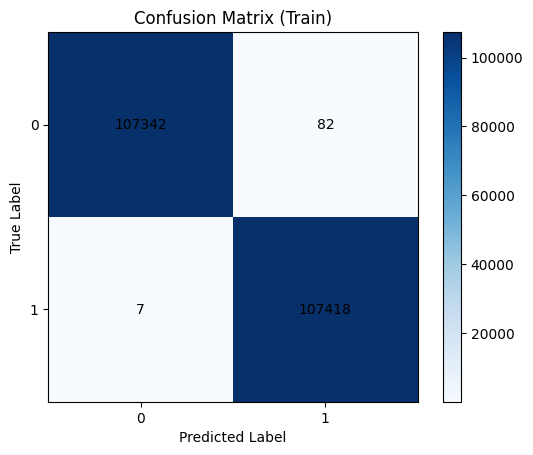

In [ ]:
# 학습 데이터를 활용한 confusion matrix

plt.imshow(cm_train, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix (Train)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_train)))
plt.xticks(tick_marks, np.unique(y_train))
plt.yticks(tick_marks, np.unique(y_train))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 셀에 숫자 표시
for i in range(cm_train.shape[0]):
    for j in range(cm_train.shape[1]):
        plt.text(j, i, cm_train[i, j], ha="center", va="center", color="black")


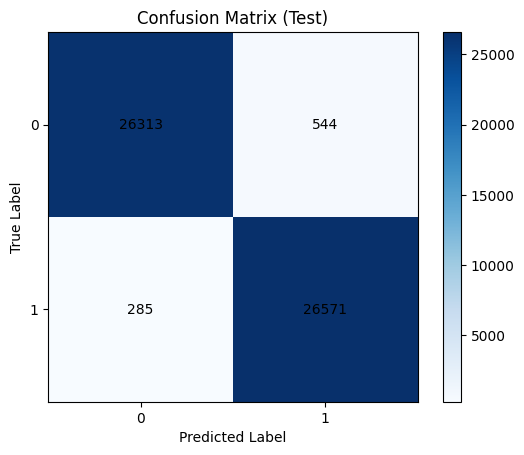

In [ ]:
# 평가 데이터를 활용한 confusion matrix

plt.imshow(cm_test, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 셀에 숫자 표시
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        plt.text(j, i, cm_test[i, j], ha="center", va="center", color="black")

In [ ]:
# coeff_df = pd.DataFrame({'feature': X_train.columns, 'coefficient': logistic_reg.coef_.flatten()})

# # 계수의 절대값을 기준으로 내림차순 정렬
# coeff_df['abs_coefficient'] = coeff_df['coefficient'].abs()
# coeff_df_sorted = coeff_df.sort_values(by='abs_coefficient', ascending=False)

# # 변수의 영향력을 확인
# coeff_df_sorted

RFC_model.feature_importances_

array([0.07466517, 0.05745734, 0.20077562, 0.1254529 , 0.12287394,
       0.07104431, 0.16182501, 0.07928601, 0.10661969])

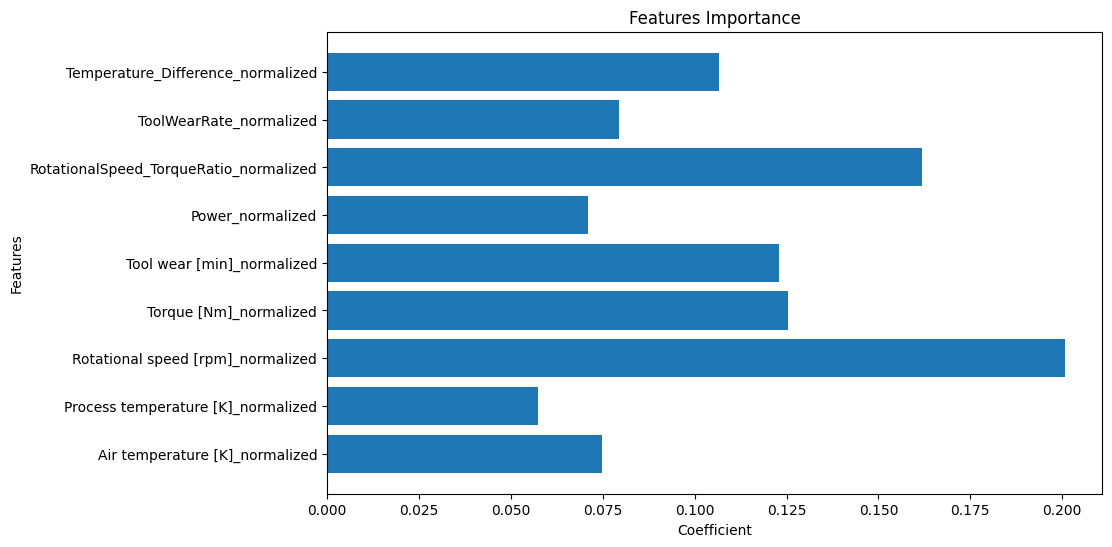

In [ ]:
# 변수 영향력 시각화
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns, RFC_model.feature_importances_)
plt.xlabel('Coefficient')
plt.ylabel('Features')
plt.title('Features Importance')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# 파라미터 그리드 설정
param_grid = {
    'n_estimators': [100, 200, 300],  # 트리의 수
    'max_features': ['auto', 'sqrt', 'log2'],  # 최대 특성 수
    'max_depth': [None, 10, 20, 30],  # 최대 트리 깊이
    'min_samples_split': [2, 5, 10],  # 노드를 분할하기 위한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4],  # 리프 노드의 최소 샘플 수
    'bootstrap': [True, False]  # 부트스트랩 샘플링 사용 여부
}


# GridSearchCV 설정
grid_search = GridSearchCV(estimator=RFC_model, param_grid=param_grid, cv=2, scoring='accuracy')

# 그리드 서치 실행
grid_search.fit(X_train, y_train)

# 결과 출력
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

# 테스트 세트에서 성능 평가
test_score = grid_search.score(X_test, y_test)
print("Test set score: {:.2f}".format(test_score))

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: Fut